# End-to-End Credit Risk Analytics & Portfolio Optimization

# Sprint 4 - Predictive Modeling

## Objective

Build a machine learning model to predict whether a loan applicant is likely to default based on demographic, financial, and employment-related features.

We begin with Logistic Regression as a baseline model before developing more advanced models in later sprints.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Load cleaned dataset
df = pd.read_csv("../data/processed/application_train_clean.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (307511, 112)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,YEARS_EMPLOYED,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,HAS_CAR,HAS_REALTY
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,1.0,25,1.745205,2.007889,0.121978,0,1
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,45,3.254795,4.790750,0.132217,0,0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,52,0.616438,2.000000,0.100000,1,1
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,1.0,52,8.326027,2.316167,0.219900,0,1
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,54,8.323288,4.222222,0.179963,0,1


In [2]:
df.dtypes.value_counts()

float64    54
int64      43
str        15
Name: count, dtype: int64

In [3]:
categorical_cols = df.select_dtypes(include=["object", "string"]).columns

print("Number of categorical columns:", len(categorical_cols))

categorical_cols

Number of categorical columns: 15


Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'HOUSETYPE_MODE',
       'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='str')

## Encoding Categorical Variables

Machine learning algorithms require numerical input.

Categorical variables are converted into numerical features using One-Hot Encoding.

In [4]:
print("Shape before encoding:", df.shape)

Shape before encoding: (307511, 112)


In [5]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print("Encoding completed!")

Encoding completed!


In [6]:
print("Shape after encoding:", df_encoded.shape)

Shape after encoding: (307511, 223)


In [7]:
df_encoded.head()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,HOUSETYPE_MODE_terraced house,WALLSMATERIAL_MODE_Mixed,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Unknown,WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_Unknown,EMERGENCYSTATE_MODE_Yes
0,100002,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637.0,...,False,False,False,False,False,True,False,False,False,False
1,100003,0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,-1188.0,...,False,False,False,False,False,False,False,False,False,False
2,100004,0,0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046,-225.0,...,False,False,False,False,False,False,True,False,True,False
3,100006,0,0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005,-3039.0,...,False,False,False,False,False,False,True,False,True,False
4,100007,0,0,121500.0,513000.0,21865.5,513000.0,0.028663,-19932,-3038.0,...,False,False,False,False,False,False,True,False,True,False


## Convert Boolean Features to Integer

Convert boolean dummy variables (`True`/`False`) into numeric values (`1`/`0`) for consistency before model training.

In [8]:
bool_cols = df_encoded.select_dtypes(include="bool").columns

print("Number of Boolean Columns:", len(bool_cols))

bool_cols[:10]

Number of Boolean Columns: 126


Index(['NAME_CONTRACT_TYPE_Revolving loans', 'CODE_GENDER_M',
       'CODE_GENDER_XNA', 'FLAG_OWN_CAR_Y', 'FLAG_OWN_REALTY_Y',
       'NAME_TYPE_SUITE_Family', 'NAME_TYPE_SUITE_Group of people',
       'NAME_TYPE_SUITE_Other_A', 'NAME_TYPE_SUITE_Other_B',
       'NAME_TYPE_SUITE_Spouse, partner'],
      dtype='str')

In [9]:
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("Boolean columns converted successfully!")

Boolean columns converted successfully!


In [10]:
df_encoded[bool_cols].head()

,NAME_CONTRACT_TYPE_Revolving loans,CODE_GENDER_M,CODE_GENDER_XNA,FLAG_OWN_CAR_Y,FLAG_OWN_REALTY_Y,NAME_TYPE_SUITE_Family,NAME_TYPE_SUITE_Group of people,NAME_TYPE_SUITE_Other_A,NAME_TYPE_SUITE_Other_B,"NAME_TYPE_SUITE_Spouse, partner",...,HOUSETYPE_MODE_terraced house,WALLSMATERIAL_MODE_Mixed,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Unknown,WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_Unknown,EMERGENCYSTATE_MODE_Yes
0,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,1,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
3,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
4,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0


## Check Remaining Missing Values

Verify that the encoded dataset contains no missing values before training the machine learning model.

In [11]:
missing = df_encoded.isnull().sum()

missing = missing[missing > 0]

print("Columns with Missing Values:", len(missing))

missing.sort_values(ascending=False).head(20)

Columns with Missing Values: 1


OWN_CAR_AGE    202929
dtype: int64

In [12]:
print("Total Missing Values:", df_encoded.isnull().sum().sum())

Total Missing Values: 202929


## Handle Remaining Missing Values

The remaining missing values belong to `OWN_CAR_AGE`.

Since applicants without a car naturally do not have a car age, the missing values are replaced with **0** while retaining the engineered `HAS_CAR` feature.

In [13]:
df_encoded["OWN_CAR_AGE"] = df_encoded["OWN_CAR_AGE"].fillna(0)

print("OWN_CAR_AGE missing values handled.")

OWN_CAR_AGE missing values handled.


In [14]:
print("Remaining Missing Values:")

print(df_encoded.isnull().sum().sum())

Remaining Missing Values:
0


## Save Machine Learning Dataset

Save the fully processed dataset after encoding and missing value treatment.

This dataset will be reused for Logistic Regression, XGBoost, and future experiments.

In [15]:
df_encoded.to_csv(
    "../data/processed/application_train_ml.csv",
    index=False
)

print("✅ Machine Learning dataset saved successfully!")

print(df_encoded.shape)

✅ Machine Learning dataset saved successfully!
(307511, 223)


## Separate Features and Target Variable

The target variable (`TARGET`) represents whether a customer defaulted on a loan.

- TARGET = 1 → Default
- TARGET = 0 → No Default

The remaining columns are used as input features.

In [16]:
# Features
X = df_encoded.drop(columns=["TARGET"])

# Target
y = df_encoded["TARGET"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (307511, 222)
Target Shape: (307511,)


## Remove Identifier Column

Customer IDs do not contain useful information for prediction and are removed before model training.

In [17]:
X = X.drop(columns=["SK_ID_CURR"])

print("Updated Feature Matrix Shape:", X.shape)

Updated Feature Matrix Shape: (307511, 221)


## Train-Test Split

Split the dataset into training and testing sets.

- 80% Training
- 20% Testing

A fixed random state is used to ensure reproducibility.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (246008, 221)
Testing Set: (61503, 221)


## Verify Class Distribution

Confirm that the class imbalance is preserved in both the training and testing datasets using stratified sampling.

In [19]:
print("Training Target Distribution")
print(y_train.value_counts(normalize=True))

print("\nTesting Target Distribution")
print(y_test.value_counts(normalize=True))

Training Target Distribution
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Testing Target Distribution
TARGET
0    0.919272
1    0.080728
Name: proportion, dtype: float64


## Feature Scaling

Logistic Regression performs better when numerical features are standardized.

We use `StandardScaler` and fit it **only on the training data** to prevent data leakage.

In [20]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [21]:
print("Scaled Training Shape:", X_train_scaled.shape)
print("Scaled Testing Shape:", X_test_scaled.shape)

Scaled Training Shape: (246008, 221)
Scaled Testing Shape: (61503, 221)


In [22]:
print("Mean of first feature:", X_train_scaled[:, 0].mean())
print("Standard deviation of first feature:", X_train_scaled[:, 0].std())

Mean of first feature: -6.654622870765467e-17
Standard deviation of first feature: 0.9999999999999999


## Logistic Regression Model

Train a Logistic Regression classifier to predict whether a customer will default on a loan.

This serves as the baseline model for comparison with more advanced models such as XGBoost.

In [23]:
from sklearn.linear_model import LogisticRegression

# Create model
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train model
log_model.fit(X_train_scaled, y_train)

print("✅ Logistic Regression model trained successfully!")

✅ Logistic Regression model trained successfully!


## Generate Predictions

Predict both:

- Class labels (0 or 1)
- Probability of default

In [24]:
# Predict classes
y_pred = log_model.predict(X_test_scaled)

# Predict probabilities
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully!")

print(y_pred[:10])

Predictions generated successfully!
[0 0 0 0 0 0 0 0 0 0]


## Model Accuracy

Calculate the percentage of correctly classified loan applications.

In [25]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9195


In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.55      0.01      0.03      4965

    accuracy                           0.92     61503
   macro avg       0.74      0.51      0.49     61503
weighted avg       0.89      0.92      0.88     61503



In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[56485    53]
 [ 4899    66]]


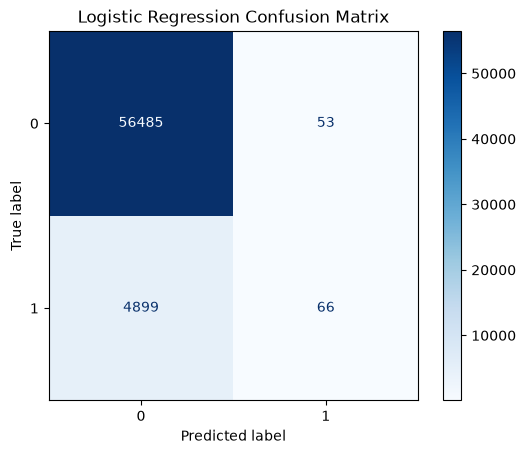

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    log_model,
    X_test_scaled,
    y_test,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [29]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.7489


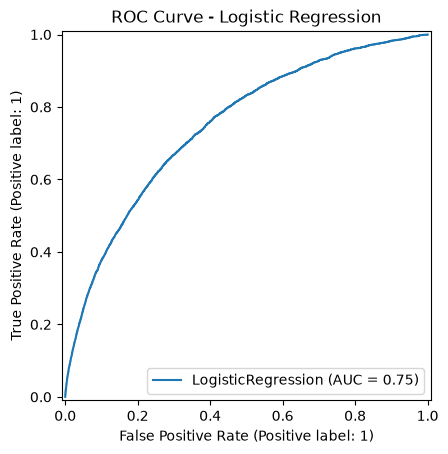

In [30]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    log_model,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve - Logistic Regression")
plt.show()

## XGBoost Model

Train an XGBoost classifier to predict customer loan default.

XGBoost is one of the most widely used machine learning algorithms in banking and financial risk analytics due to its excellent predictive performance.

In [31]:
from xgboost import XGBClassifier

In [32]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Scale Pos Weight:", scale_pos_weight)

xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

Scale Pos Weight: 11.38710976837865


In [33]:
xgb_model.fit(X_train, y_train)

print("✅ XGBoost model trained successfully!")

✅ XGBoost model trained successfully!


In [34]:
xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("Predictions generated!")
print(xgb_pred[:10])

Predictions generated!
[0 0 1 0 0 1 0 0 1 0]


In [35]:
from sklearn.metrics import accuracy_score

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print(f"Accuracy: {xgb_accuracy:.4f}")

Accuracy: 0.7155


In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.96      0.72      0.82     56538
           1       0.17      0.66      0.27      4965

    accuracy                           0.72     61503
   macro avg       0.57      0.69      0.55     61503
weighted avg       0.90      0.72      0.78     61503



In [37]:
from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(y_test, xgb_pred)

print(cm_xgb)

[[40737 15801]
 [ 1696  3269]]


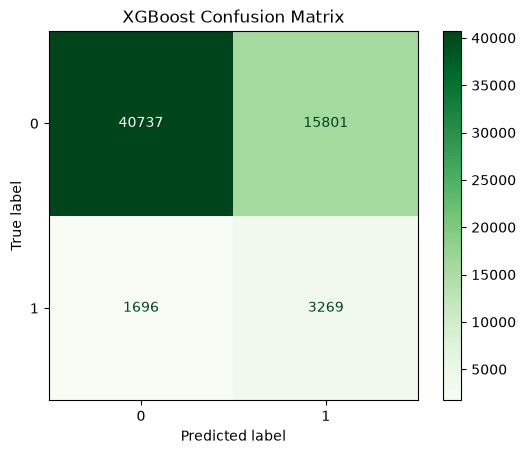

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    xgb_model,
    X_test,
    y_test,
    cmap="Greens"
)

plt.title("XGBoost Confusion Matrix")
plt.show()

In [39]:
from sklearn.metrics import roc_auc_score

xgb_auc = roc_auc_score(y_test, xgb_prob)

print(f"ROC-AUC: {xgb_auc:.4f}")

ROC-AUC: 0.7568


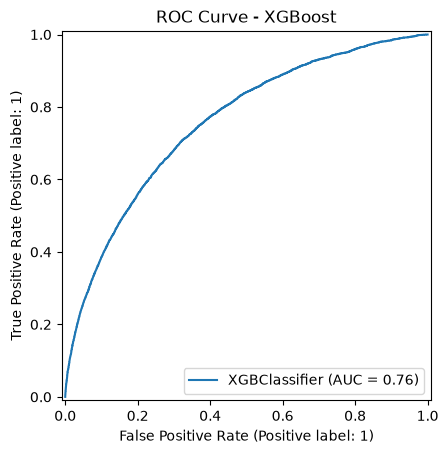

In [40]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    xgb_model,
    X_test,
    y_test
)

plt.title("ROC Curve - XGBoost")
plt.show()

In [41]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, xgb_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9195,0.5546,0.0133,0.026,0.7489
1,XGBoost,0.7155,0.1714,0.6584,0.272,0.7568


In [42]:
X.to_csv("../data/processed/model_features.csv", index=False)

print("✅ Model features saved successfully!")
print(X.shape)

✅ Model features saved successfully!
(307511, 221)
